# Lib

In [2]:
from pathlib import Path
import os
import cv2
import glob
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

from face_recognition import *

import warnings
warnings.filterwarnings("ignore")

# path

In [3]:
TRAIN_DIR = "../../dataset_face_recognition/train"
TEST_DIR = "../../dataset_face_recognition/test"
RAW_DIR = "../../dataset_face_recognition/raw"
PREPROCESSED_DIR_TRAIN = "../../dataset_face_recognition/processed/train"
PREPROCESSED_DIR_TEST = "../../dataset_face_recognition/processed/test"
TRAIN_DIR = Path(TRAIN_DIR)
TEST_DIR = Path(TEST_DIR)
RAW_DIR = Path(RAW_DIR)
PREPROCESSED_DIR_TRAIN = Path(PREPROCESSED_DIR_TRAIN)
PREPROCESSED_DIR_TEST = Path(PREPROCESSED_DIR_TEST)

In [4]:
print(TRAIN_DIR)
print(TEST_DIR)
print(RAW_DIR)
print(PREPROCESSED_DIR_TRAIN)
print(PREPROCESSED_DIR_TEST)

..\..\dataset_face_recognition\train
..\..\dataset_face_recognition\test
..\..\dataset_face_recognition\raw
..\..\dataset_face_recognition\processed\train
..\..\dataset_face_recognition\processed\test


# Utils

In [5]:
def load_processed_data(data_dir):
    X = []
    y = []
    class_names = []

    classes = [
        d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))
    ]
    classes.sort()

    for label, person_name in enumerate(classes):
        class_names.append(person_name)
        person_dir = os.path.join(data_dir, person_name)

        for img_name in os.listdir(person_dir):
            img_path = os.path.join(person_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                X.append(img.flatten())
                y.append(label)

    return np.array(X), np.array(y), class_names

# Main

In [6]:
X_train, y_train, class_names = load_processed_data(PREPROCESSED_DIR_TRAIN)

In [7]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)

In [8]:
df_info = pd.DataFrame({
    "Info": ["Total images", "Number of features (Pixels)", "Number of classes"],
    "Value": [X_train.shape[0], X_train.shape[1], len(class_names)]
})
df_info

,Info,Value
0,Total images,2388
1,Number of features (Pixels),62500
2,Number of classes,31


## Eigenfaces

In [9]:
pca = PCA(n_components=0.90).fit(X_train)

X_train_pca = pca.transform(X_train)
n_components = pca.n_components_

print(f"Eigenfaces: {n_components}")
print(f"Shape     : {X_train_pca.shape}")

Eigenfaces: 160
Shape     : (2388, 160)


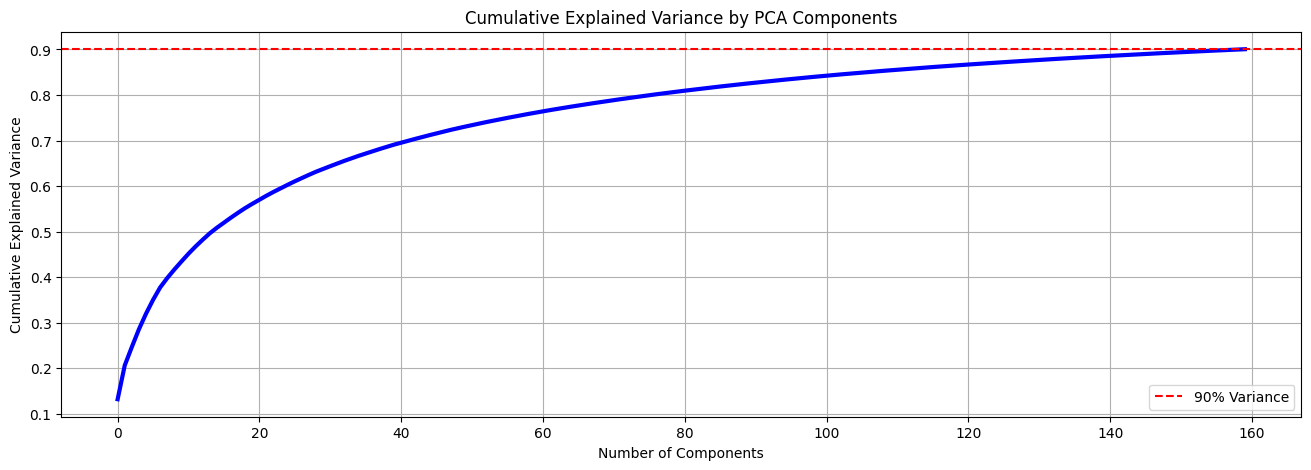

In [10]:
plt.figure(figsize=(16, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), linewidth=3, color="blue")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.grid(True)
plt.axhline(y=0.90, color="r", linestyle="--", label=f"90% Variance")
plt.legend()
plt.show()

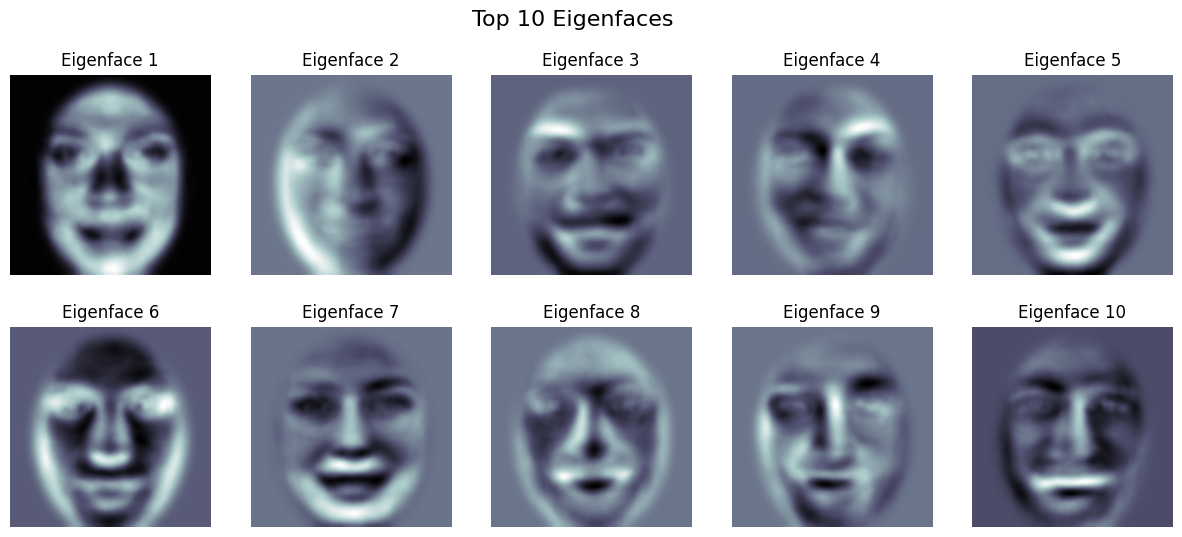

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Top 10 Eigenfaces", fontsize=16)
for i, ax in enumerate(axes.flat):
    eigenface = pca.components_[i].reshape(250, 250)
    ax.imshow(eigenface, cmap="bone")
    ax.set_title(f"Eigenface {i+1}")
    ax.axis("off")
plt.show()

## Fisherfaces

In [12]:
lda = LDA()
X_train_lda = lda.fit_transform(X_train_pca, y_train)

print(f"Fisherfaces: {n_components}")
print(f"Shape      : {X_train_pca.shape}")

Fisherfaces: 160
Shape      : (2388, 160)


In [13]:
fisherfaces = lda.scalings_

print("Shape fisherfaces:", fisherfaces.shape)

Shape fisherfaces: (160, 30)


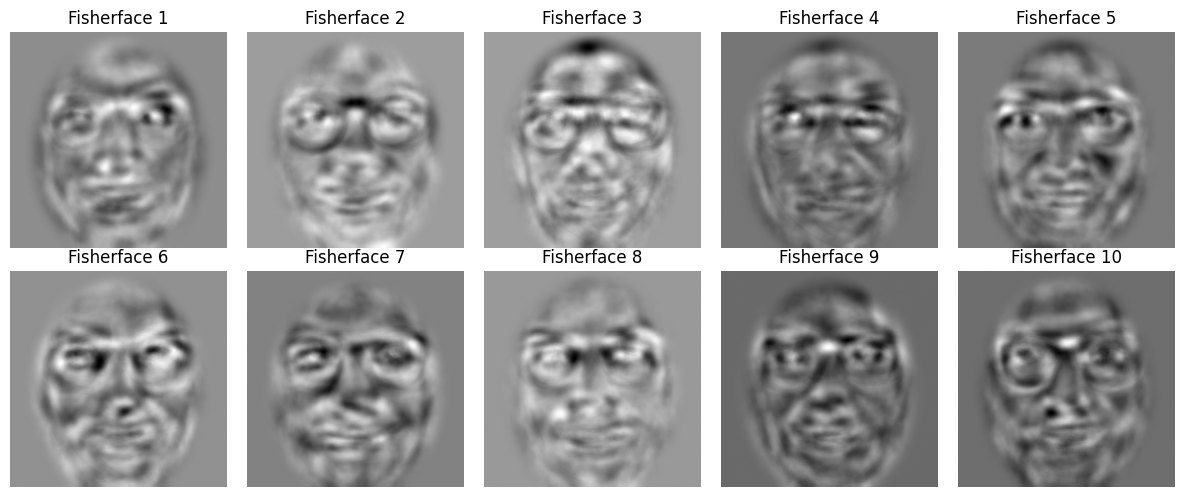

In [14]:
h, w = 250, 250

fisherfaces_original = pca.components_.T @ lda.scalings_

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    if i < fisherfaces_original.shape[1]:
        fisherface = fisherfaces_original[:, i]

        fisherface = (fisherface - fisherface.min()) / (
            fisherface.max() - fisherface.min()
        )

        ax.imshow(fisherface.reshape(h, w), cmap='gray')
        ax.set_title(f"Fisherface {i+1}")
        ax.axis('off')

plt.tight_layout()
plt.show()

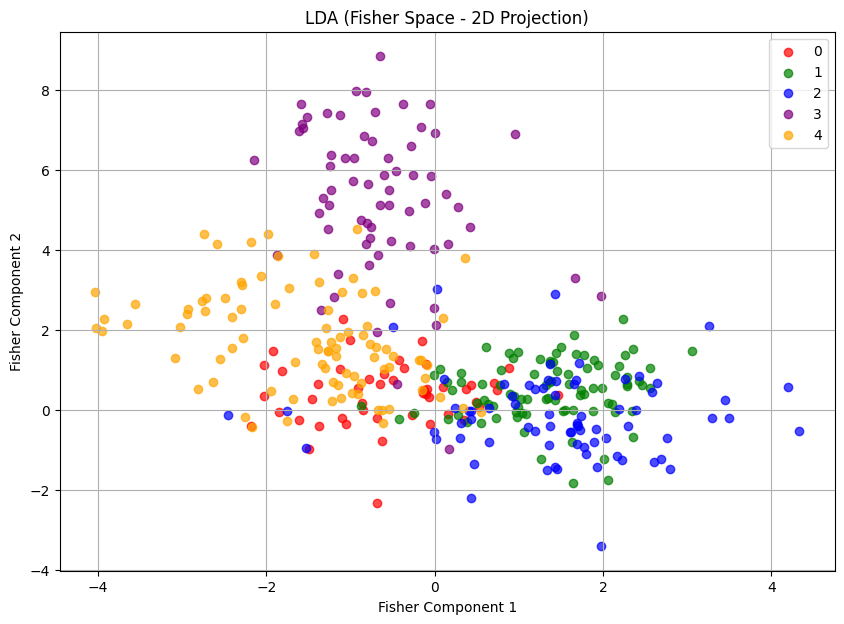

In [15]:
plt.figure(figsize=(10, 7))
colors = ["red", "green", "blue", "purple", "orange"]
for i in range(5):
    idx = y_train == i
    plt.scatter(
        X_train_lda[idx, 0],
        X_train_lda[idx, 1],
        alpha=0.7,
        color=colors[i],
        label=le.inverse_transform([i])[0],
    )

plt.title("LDA (Fisher Space - 2D Projection)")
plt.xlabel("Fisher Component 1")
plt.ylabel("Fisher Component 2")
plt.legend()
plt.grid(True)
plt.show()

# Train

In [17]:
classifier = KNeighborsClassifier(n_neighbors=1, metric="euclidean", n_jobs=-1)
classifier.fit(X_train_lda, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](31,)","[ 0, 1, 2,...,28,29,30]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


# Eval

In [ ]:
X_test, y_test, _ = load_processed_data(PREPROCESSED_DIR_TEST)
y_test = le.transform(y_test)

In [ ]:
y_pred = classifier.predict(lda.transform(pca.transform(X_test)))

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))

                    precision    recall  f1-score   support

      Akshay Kumar       1.00      0.89      0.94        18
Alexandra Daddario       0.85      0.97      0.90        34
        Alia Bhatt       0.97      0.93      0.95        30
  Amitabh Bachchan       1.00      0.88      0.93        24
      Andy Samberg       0.89      1.00      0.94        34
    Anushka Sharma       0.96      0.96      0.96        25
     Billie Eilish       0.96      0.86      0.91        28
         Brad Pitt       1.00      0.98      0.99        43
    Camila Cabello       0.93      0.93      0.93        30
   Charlize Theron       0.89      0.92      0.91        26
       Claire Holt       0.94      0.97      0.95        32
      Courtney Cox       0.96      0.96      0.96        28
    Dwayne Johnson       1.00      1.00      1.00        25
   Elizabeth Olsen       1.00      1.00      1.00        28
   Ellen Degeneres       1.00      0.93      0.96        27
      Henry Cavill       0.97      0.97

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

results_df = pd.DataFrame({
    "Model": ["Fisherfaces (PCA + LDA)"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1-score": [f1]
})
results_df.round(4)

,Model,accuracy,precision,recall,f1-score
0,Fisherfaces (PCA + LDA),0.9573,0.959,0.9573,0.9574


# Export

In [ ]:
model_package = {
    "pca": pca,
    "lda": lda,
    "classifier": classifier,
    "class_names": class_names,
}

model_path = "../../model/fisherfaces_model.pkl"
joblib.dump(model_package, model_path)

['../../model/fisherfaces_model.pkl']